<a href="https://colab.research.google.com/github/LinglinNero/MSSP607/blob/main/Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#connect to github file
from google.colab import userdata
import os

github_token = userdata.get('Git_Hub')
owner = 'LinglinNero'
repository = 'MSSP607'

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

# Clone the repository
!git clone {clone_url}

Cloning into 'MSSP607'...
remote: Enumerating objects: 188, done.
remote: Counting objects: 100% (188/188), done.
remote: Compressing objects: 100% (164/164), done.
remote: Total 188 (delta 79), reused 34 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (188/188), 7.80 MiB | 4.86 MiB/s, done.
Resolving deltas: 100% (79/79), done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import normaltest
from scipy.stats import norm
from scipy.stats.mstats import winsorize
from scipy.stats import mannwhitneyu


In [4]:
#data overview
df = pd.read_csv('/content/drive/MyDrive/MSSP607/Assignments/Final/employee_earnings.csv', encoding= 'latin1')
df.info()
#missing value
missing = df.isnull().sum()
print(missing)
#category
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
print(list(categorical_cols))

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 808653 entries, 0 to 808652
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   the_geom                       0 non-null       float64
 1   cartodb_id                     808653 non-null  int64  
 2   the_geom_webmercator           0 non-null       float64
 3   objectid                       808653 non-null  int64  
 4   calendar_year                  808653 non-null  int64  
 5   quarter                        808653 non-null  int64  
 6   last_name                      808653 non-null  object 
 7   first_name                     808653 non-null  object 
 8   title                          808653 non-null  object 
 9   job_code                       808653 non-null  object 
 10  department_name                808653 non-null  object 
 11  department_number              808653 non-null  int64  
 12  base_salary                   

delete 0 line NA data
without outlier, there are771885 line data 


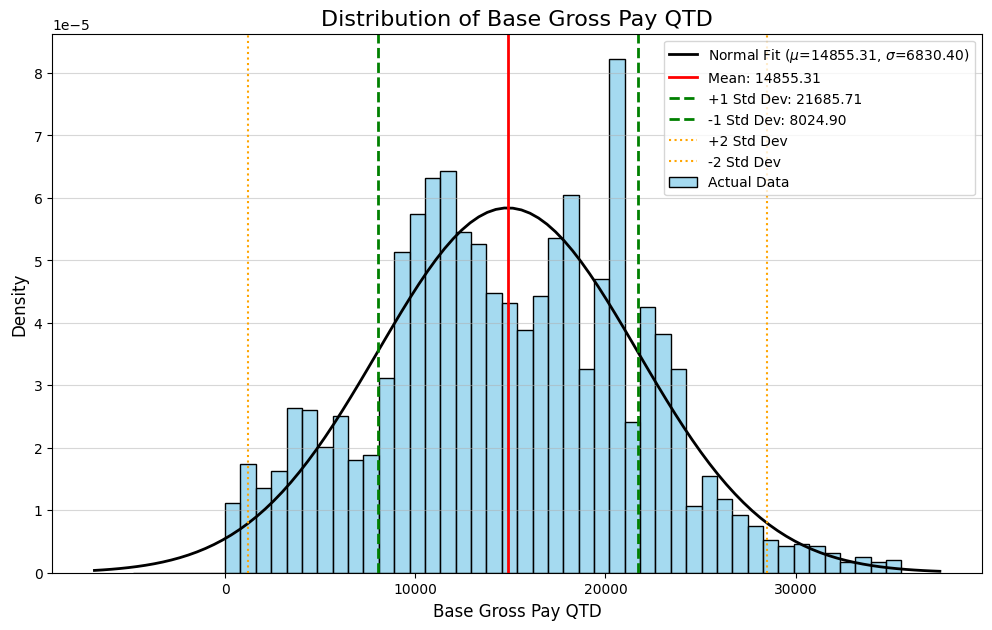

Mean: 14855.31
Std: 6830.40


In [5]:
#data preparation
original_count = len(df)
df_clean = df.dropna(subset=['base_gross_pay_qtd']).copy()
print(f"delete {original_count - len(df_clean)} line NA data")

#Outlier
Q1 = df_clean['base_gross_pay_qtd'].quantile(0.25)
Q3 = df_clean['base_gross_pay_qtd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_final = df_clean[(df_clean['base_gross_pay_qtd'] >= lower_bound) &
                    (df_clean['base_gross_pay_qtd'] <= upper_bound) &
                     df_clean['base_gross_pay_qtd'] > 0
                    ]


print(f"without outlier, there are{len(df_final)} line data ")


plt.figure(figsize=(12, 7))
data_to_plot = df_final['base_gross_pay_qtd']
mu, std = norm.fit(data_to_plot)

sns.histplot(data_to_plot, bins=50, kde=False, stat="density", color="skyblue", label="Actual Data")
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=rf'Normal Fit ($\mu$={mu:.2f}, $\sigma$={std:.2f})')


plt.axvline(mu, color='red', linestyle='-', linewidth=2, label=f'Mean: {mu:.2f}')
plt.axvline(mu + std, color='green', linestyle='--', linewidth=2, label=f'+1 Std Dev: {mu+std:.2f}')
plt.axvline(mu - std, color='green', linestyle='--', linewidth=2, label=f'-1 Std Dev: {mu-std:.2f}')
plt.axvline(mu + 2*std, color='orange', linestyle=':', label='+2 Std Dev')
plt.axvline(mu - 2*std, color='orange', linestyle=':', label='-2 Std Dev')


plt.title('Distribution of Base Gross Pay QTD', fontsize=16)
plt.xlabel('Base Gross Pay QTD', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.5)

plt.show()

print(f"Mean: {mu:.2f}")
print(f"Std: {std:.2f}")

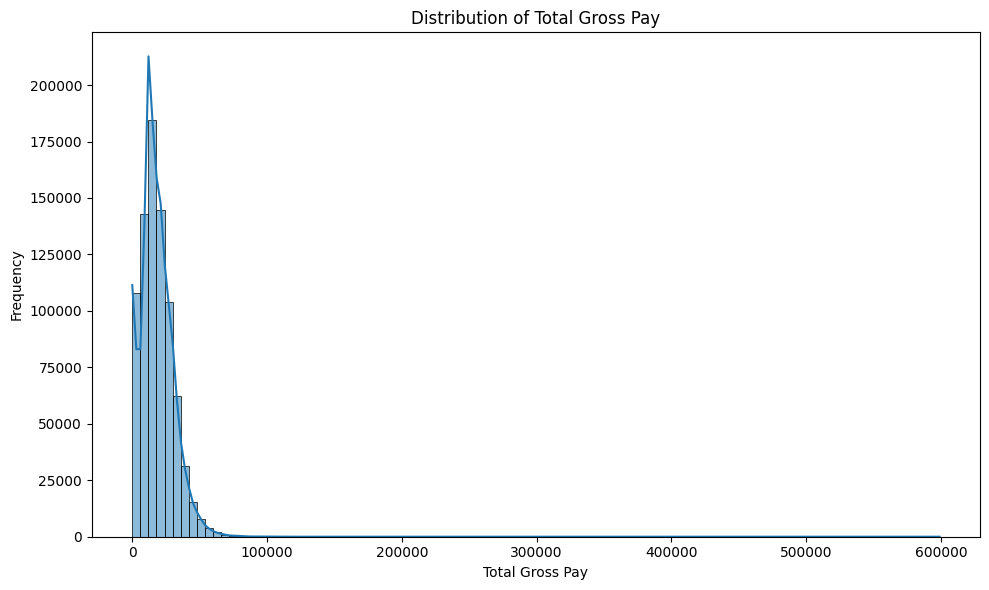

p-value: 0.0


In [6]:
#goal 1：which department has the most high salary
df['overtime_gross_pay_qtd'] = df['overtime_gross_pay_qtd'].fillna(0)
df['longevity_gross_pay_qtd'] = df['longevity_gross_pay_qtd'].fillna(0)
df['post_separation_gross_pay_qtd'] = df['post_separation_gross_pay_qtd'].fillna(0)

df['total_gross_qtd'] = (
    df['base_gross_pay_qtd']
    + df['overtime_gross_pay_qtd']
    + df['longevity_gross_pay_qtd']
    + df['miscellaneous_gross_pay_qtd']
)

df = df[df['total_gross_qtd']>= 0]

#normal distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['total_gross_qtd'], bins=100, kde=True)
plt.title('Distribution of Total Gross Pay')
plt.xlabel('Total Gross Pay')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

sample_for_test = df['total_gross_qtd'].dropna().sample(20000, random_state=0)
stat, p = normaltest(sample_for_test)
alpha = 0.05
print('p-value:', p)




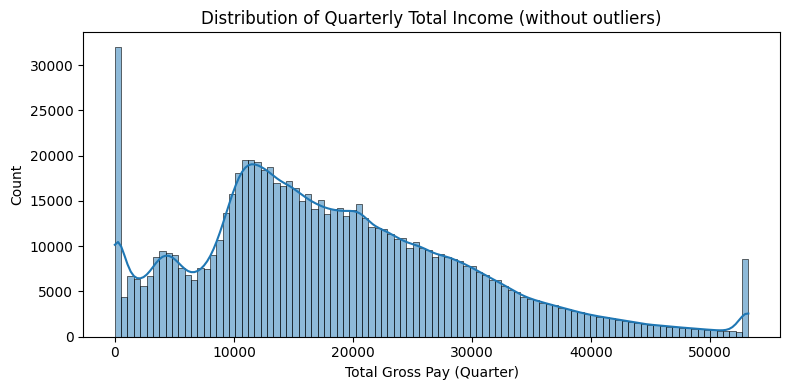

In [7]:
#outlier fix
winsorized_values = winsorize(df["total_gross_qtd"], limits=[0.01, 0.01])
df["total_gross_qtd_winsor"] = np.array(winsorized_values)

plt.figure(figsize=(8, 4))
sns.histplot(df["total_gross_qtd_winsor"], bins=100, kde=True)
plt.title("Distribution of Quarterly Total Income (without outliers)")
plt.xlabel("Total Gross Pay (Quarter)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


=== Top 10 departments by mean quarterly income(without outliers) ===
                                        mean     median   count
department_name                                                
PFD Fire                        29480.039559  29313.670   74271
PPD Police                      24643.699180  25314.390  194765
OAC Ofc Arts Culture Creative   22624.813750  18640.215       8
BOE Board of Ethics             22346.656818  20564.255     264
COM Commerce                    20994.735697  19401.110     509
MOE Mayors Office of Education  19422.649856  17514.400    1456
OIG Ofc of Inspector General    19286.826976  18545.110     506
OIT Ofc of Innovation and Tech  19219.585881  19149.600   13499
LAW Law Dept                    18886.279228  18172.130    9163
CTO City Treasurer              18565.830778  17240.570     501


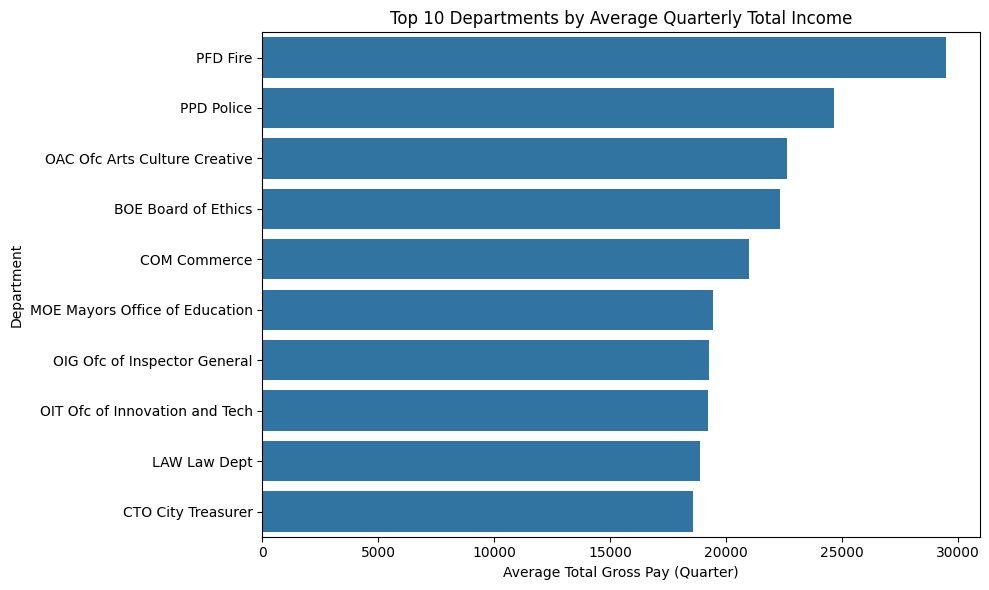

In [8]:
dept_stats_win = df.groupby("department_name")["total_gross_qtd_winsor"].agg(
    mean="mean",
    median="median",
    count="count"
).sort_values("mean", ascending=False)

print("\n=== Top 10 departments by mean quarterly income(without outliers) ===")
print(dept_stats_win.head(10))

top10_win = dept_stats_win.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top10_win["mean"],
    y=top10_win.index
)
plt.title("Top 10 Departments by Average Quarterly Total Income")
plt.xlabel("Average Total Gross Pay (Quarter)")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-1750514054.py:11: SyntaxWarning: invalid escape sequence '\D'
  print("\Departments Ranked by OT Ratio")


\Departments Ranked by OT Ratio
                                  OT_sum  Total_pay_sum  OT_ratio
department_name                                                  
PPS Prisons                 1.777427e+08   7.616570e+08  0.233363
SAN Sanitation              5.232263e+06   2.310644e+07  0.226442
PFD Fire                    4.632790e+08   2.212286e+09  0.209412
SHF Sheriff                 3.285496e+07   1.743469e+08  0.188446
PHL Dept of Aviation        2.391138e+07   1.279250e+08  0.186917
CMS City Commissioners      9.802515e+06   5.462421e+07  0.179454
STS Streets                 1.186245e+08   7.337441e+08  0.161670
PPD Police                  7.469707e+08   4.835400e+09  0.154480
DHS Dept of Human Services  9.860635e+07   6.463123e+08  0.152568
DFS Dept of Fleet Services  1.349989e+07   9.031168e+07  0.149481


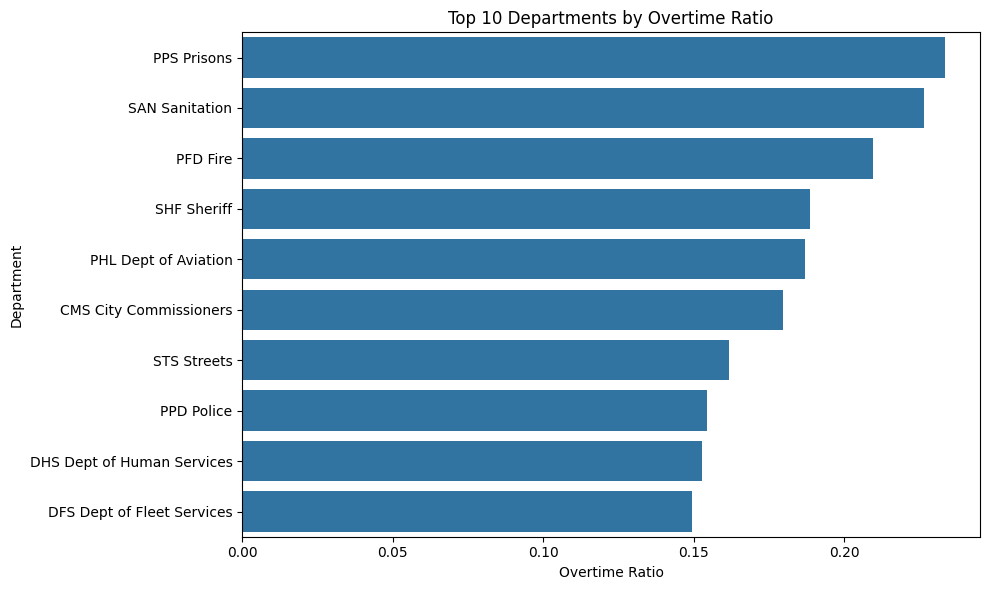

In [9]:
#goal2: overtime ratio
dept_ot_sum = df.groupby("department_name")["overtime_gross_pay_qtd"].sum()
dept_total_sum = df.groupby("department_name")["total_gross_qtd"].sum()
dept_ot_ratio = (dept_ot_sum / dept_total_sum).sort_values(ascending=False)
dept_ot_stats = pd.DataFrame({
    "OT_sum": dept_ot_sum,
    "Total_pay_sum": dept_total_sum,
    "OT_ratio": dept_ot_ratio
}).sort_values("OT_ratio", ascending=False)

print("\Departments Ranked by OT Ratio")
print(dept_ot_stats.head(10))

top10_ot_ratio = dept_ot_stats.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top10_ot_ratio["OT_ratio"], y=top10_ot_ratio.index)
plt.xlabel("Overtime Ratio")
plt.ylabel("Department")
plt.title("Top 10 Departments by Overtime Ratio")
plt.tight_layout()
plt.show()

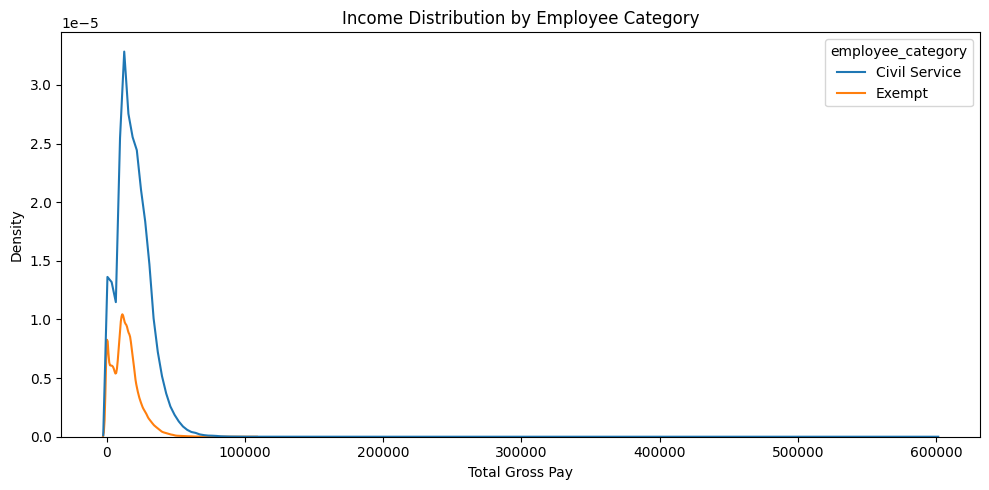


normal distribution test D’Agostino K²）:
Civil Service p: 0.0
Exempt        p: 0.0
Mann-Whitney U Test p-value: 0.0
Median Income (Civil Service): 18303.94
Median Income (Exempt): 12882.395


In [10]:
#goal 3: Equity(employee category)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="total_gross_qtd", hue="employee_category")
plt.title("Income Distribution by Employee Category")
plt.xlabel("Total Gross Pay")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


cs = df[df["employee_category"] == "Civil Service"]["total_gross_qtd"]
ex = df[df["employee_category"] == "Exempt"]["total_gross_qtd"]
cs_sample = cs.sample(min(20000, len(cs)), random_state=0)
ex_sample = ex.sample(min(20000, len(ex)), random_state=0)

stat_cs, p_cs = normaltest(cs_sample)
stat_ex, p_ex = normaltest(ex_sample)

print("\nnormal distribution test D’Agostino K²）:")
print("Civil Service p:", p_cs)
print("Exempt        p:", p_ex)
stat, p_val = mannwhitneyu(cs, ex, alternative='two-sided')
print(f"Mann-Whitney U Test p-value: {p_val}")


print("Median Income (Civil Service):", cs.median())
print("Median Income (Exempt):", ex.median())